# K 近邻算法

https://www.runoob.com/ml/ml-knn.html

## KNN

### KNN 的基本原理

KNN 算法的基本原理可以概括为以下几个步骤：

1. 计算距离：计算待分类样本与训练集中每个样本的距离。常用的距离度量方法有欧氏距离、曼哈顿距离等。
2. 选择 K 个最近邻：根据计算出的距离，选择距离最近的 K 个样本。
2. 投票或平均：对于分类问题，K 个最近邻中出现次数最多的类别即为待分类样本的类别；对于回归问题，K 个最近邻的值的平均值即为待分类样本的值。

### KNN 的特点

- 简单易理解：KNN 算法的原理非常简单，容易理解和实现。
- 无需训练：KNN 是一种"懒惰学习"算法，不需要显式的训练过程，所有的计算都在预测时进行。
- 对数据分布无假设：KNN 不对数据的分布做任何假设，适用于各种类型的数据。
- 计算复杂度高：由于 KNN 需要在预测时计算所有样本的距离，当数据集较大时，计算复杂度会很高。

### KNN 算法的优缺点

优点

- 简单易用：KNN 算法的原理简单，易于理解和实现。
- 无需训练：KNN 不需要显式的训练过程，所有的计算都在预测时进行。
- 适用于多分类问题：KNN 可以轻松处理多分类问题。
缺点

- 计算复杂度高：KNN 需要在预测时计算所有样本的距离，当数据集较大时，计算复杂度会很高。
- 对噪声敏感：KNN 对噪声数据较为敏感，噪声数据可能会影响预测结果。
- 需要选择合适的 K 值：K 值的选择对模型的性能有很大影响，选择合适的 K 值是一个挑战。

## KNN 算法的实现步骤

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

在应用 KNN 算法之前，通常需要对数据进行标准化处理，以确保每个特征对距离计算的贡献是相同的。

In [3]:
# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

接下来，我们使用 sklearn 中的 KNeighborsClassifier 来训练 KNN 模型。这里我们选择 K=3，即选择 3 个最近邻。

In [4]:
# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


使用训练好的模型对测试集进行预测，并计算模型的准确率。

In [5]:
# 在测试集上进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN模型的准确率: {accuracy:.4f}")

KNN模型的准确率: 0.7556


KNN模型的准确率: 0.7556


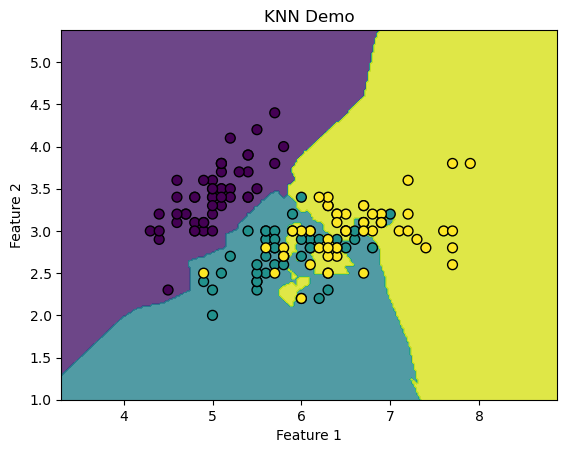

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN模型的准确率: {accuracy:.4f}")

# 绘制决策边界和数据点
h = .02  # 网格步长
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 创建一个二维网格，表示不同的样本空间
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 使用KNN模型预测网格中的每个点的类别
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.8)

# 绘制训练数据点
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50)
plt.title("KNN Demo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

调整 K 值

/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/env

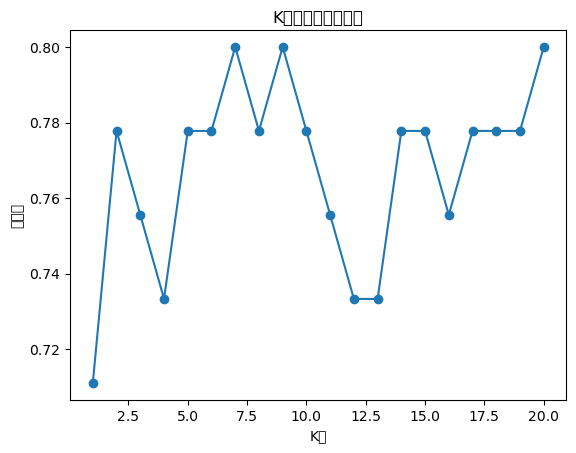

In [7]:
# 尝试不同的K值并绘制准确率变化
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# 绘制K值与准确率的关系
plt.plot(k_range, accuracies, marker='o')
plt.title("K值与准确率的关系")
plt.xlabel("K值")
plt.ylabel("准确率")
plt.show()

使用 KNN 进行回归任务

KNN 同样可以用于回归任务（KNN Regression）。

在回归任务中，KNN 根据 K 个最近邻的目标值进行平均来预测输出。

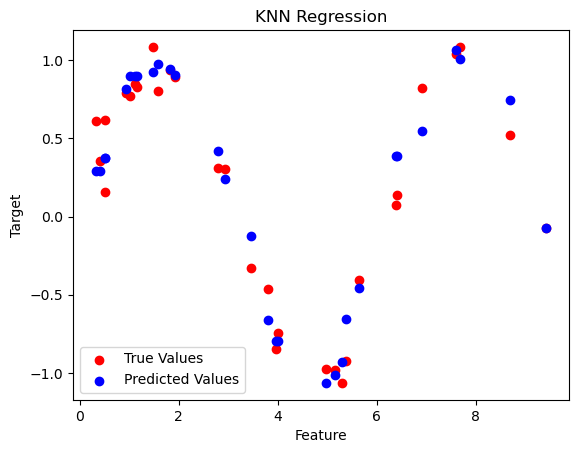

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# 生成示例数据
X = np.random.rand(100, 1) * 10
y = np.sin(X).ravel() + 0.1 * np.random.randn(100)

# 拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN回归模型
knn_reg = KNeighborsRegressor(n_neighbors=5)

# 训练模型
knn_reg.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn_reg.predict(X_test)

# 可视化回归结果
plt.scatter(X_test, y_test, color='red', label='True Values')
plt.scatter(X_test, y_pred, color='blue', label='Predicted Values')
plt.title("KNN Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

## 实现 KNN

In [28]:
class MyKNeighborsRegressor:
    def __init__(self, n_neighbors: int):
        self.n_neighbors = n_neighbors

    # x: (batch, features)
    # y: (batch, )
    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X = X
        self.y = y

    # x: (batch, features)
    def predict(self, X: np.ndarray):
        ys = []
        for b in range(len(X)):
            x = X[b] # (features)

            # 1. 计算和所有点的距离
            # 广播：(batch, features) => (batch)
            distances = np.sum((self.X - x.reshape(1, -1))**2, axis=1)

            # 2. 找到 top k 个最近的 (k, )
            idx = np.argsort(distances)[:self.n_neighbors]
            neighbors = self.y[idx] # (k, )

            # 3. 计算平均值
            ys.append(neighbors.mean().item())

        return np.array(ys)
            

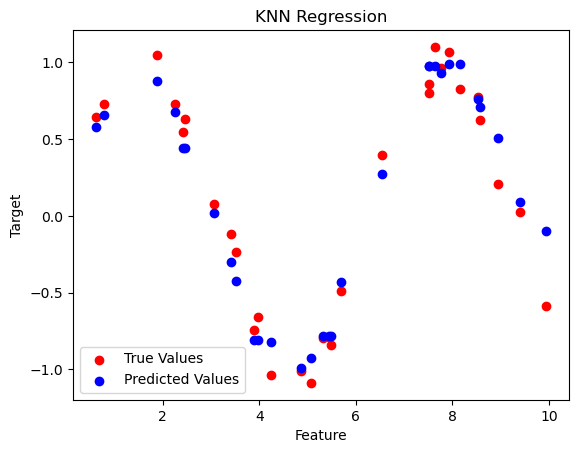

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 生成示例数据
X = np.random.rand(100, 1) * 10
y = np.sin(X).ravel() + 0.1 * np.random.randn(100)

# 拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN回归模型
knn_reg = MyKNeighborsRegressor(n_neighbors=5)

# 训练模型
knn_reg.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn_reg.predict(X_test)

# 可视化回归结果
plt.scatter(X_test, y_test, color='red', label='True Values')
plt.scatter(X_test, y_pred, color='blue', label='Predicted Values')
plt.title("KNN Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()